# 모의고사 6회 | 의료비 예측

## 📋 전체 시나리오

**배경:**
병원 데이터 분석팀에서 환자의 의료비를 예측하는 모델을 개발하려고 합니다. 
두 가지 데이터셋이 제공됩니다:
- `patient_info.json`: 환자 기본 정보
- `medical_history.csv`: 환자 의료 및 입원 정보

두 데이터셋은 `PatientID`를 공통 키로 가지며, 병합 후 의료비 예측에 필요한 특성과 타겟 변수를 사용합니다.

**목표:**
pandas를 활용한 데이터 전처리, 시각화, 그리고 여러 머신러닝 회귀 모델(Gradient Boosting, Lasso, 딥러닝)을 학습하여 
가장 성능이 좋은 모델을 선택하고 평가하는 것이 목표입니다.

---


## 문제 6-1 | 라이브러리 임포트 및 데이터 로딩

### 📌 문제
다음 작업을 수행하세요:

1. 필요한 라이브러리를 임포트하세요
   - `pandas` (별칭 `pd` 사용)
   
2. JSON 및 CSV 파일을 읽어 데이터프레임으로 로딩하세요
   - `patient_info.json` → `df_patient`
   - `medical_history.csv` → `df_medical`


In [65]:
# 라이브러리 임포트
import pandas as pd

In [66]:
# 데이터 불러오기
df_patient = pd.read_json('C:/juehyeon/aice_test/기출문제/6.의료비예측/patient_info.json')
df_medical = pd.read_csv('C:/juehyeon/aice_test/기출문제/6.의료비예측/medical_history.csv')

In [67]:
# 데이터 확인하기
df_patient.info() # 결측치 X, 범주형 변수 -> Patient ID, Gender, Smoker, Region

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PatientID        500 non-null    object 
 1   Age              500 non-null    int64  
 2   Gender           500 non-null    object 
 3   BMI              500 non-null    float64
 4   Smoker           500 non-null    object 
 5   Region           500 non-null    object 
 6   NumChildren      500 non-null    int64  
 7   MedicalCost_USD  500 non-null    float64
dtypes: float64(2), int64(2), object(4)
memory usage: 31.4+ KB


In [68]:
# 데이터 확인하기
df_medical.info() # 결측치 NumHostpializations : 2개, 범주형변수 -> PatientID

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PatientID            500 non-null    object 
 1   NumHospitalizations  480 non-null    float64
 2   ChronicDiseaseCount  500 non-null    int64  
 3   MedicationCount      500 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 15.8+ KB


## 문제 6-2 | 데이터 병합

### 📌 문제
두 개의 데이터프레임(`df_patient`, `df_medical`)을 `PatientID`를 기준으로 병합하는 코드를 작성하세요.

**요구사항:**
- pandas의 `merge` 함수를 사용하여 `df_patient`와 `df_medical`을 `PatientID`를 키로 병합
- 병합 방식은 inner join 사용
- 병합 결과 데이터프레임에 모든 데이터프레임의 모든 컬럼이 포함되어야 함


In [69]:
# 데이터 병합
df = pd.merge(df_patient, df_medical, on = 'PatientID', how = 'inner')

In [70]:
# 데이터 병합 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PatientID            500 non-null    object 
 1   Age                  500 non-null    int64  
 2   Gender               500 non-null    object 
 3   BMI                  500 non-null    float64
 4   Smoker               500 non-null    object 
 5   Region               500 non-null    object 
 6   NumChildren          500 non-null    int64  
 7   MedicalCost_USD      500 non-null    float64
 8   NumHospitalizations  480 non-null    float64
 9   ChronicDiseaseCount  500 non-null    int64  
 10  MedicationCount      500 non-null    int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 43.1+ KB


## 문제 6-3 | 불필요 컬럼 삭제

### 📌 문제
모델링에 불필요한 `PatientID` 컬럼을 삭제하는 코드를 작성하세요.

**요구사항:**
- `df`에서 `PatientID` 컬럼을 삭제


In [71]:
# 컬럼 삭제
df = df.drop(columns = 'PatientID')

In [72]:
# 컬럼 삭제 확인
df.columns

Index(['Age', 'Gender', 'BMI', 'Smoker', 'Region', 'NumChildren',
       'MedicalCost_USD', 'NumHospitalizations', 'ChronicDiseaseCount',
       'MedicationCount'],
      dtype='object')

## 문제 6-4 | 결측치 처리

### 📌 문제
`NumHospitalizations` 컬럼의 결측치가 있다고 가정하고, 해당 컬럼의 결측치를 평균값으로 대체하는 코드를 작성하세요.

**요구사항:**
- `fillna()` 함수를 사용하여 결측치를 평균값으로 채움
- `NumHospitalizations` 컬럼의 평균을 `mean_hospitalizations` 변수에 저장한 후 결측치를 대체


In [73]:
# 결측치 확인
df['NumHospitalizations'].isna().sum()

np.int64(20)

In [74]:
# 평균 구하기
mean_hospitalizations = df['NumHospitalizations'].mean()

In [75]:
mean_hospitalizations

np.float64(4.416666666666667)

In [76]:
# 평균 확인하기
df.describe() # 평균 : 4.41로 일치

,Age,BMI,NumChildren,MedicalCost_USD,NumHospitalizations,ChronicDiseaseCount,MedicationCount
count,500.000000,500.000000,500.000000,500.000000,480.000000,500.000000,500.000000
mean,49.910000,28.820800,2.026000,10963.741900,4.416667,2.028000,3.404000
std,18.221909,6.125099,1.407582,4556.492073,2.923045,1.446167,2.329729
min,18.000000,18.600000,0.000000,2660.980000,0.000000,0.000000,0.000000
25%,35.000000,23.375000,1.000000,8028.715000,2.000000,1.000000,1.000000
50%,50.000000,28.600000,2.000000,9874.030000,4.000000,2.000000,3.000000
75%,66.000000,34.050000,3.000000,12345.620000,7.000000,3.000000,6.000000
max,79.000000,40.000000,4.000000,22962.380000,9.000000,4.000000,7.000000


In [77]:
# 결측치 대체
df['NumHospitalizations'] = df['NumHospitalizations'].fillna(mean_hospitalizations)

In [78]:
# 결측치 대체 확인
df['NumHospitalizations'].isna().sum()

np.int64(0)

## 문제 6-5 | 수치형 변수 관계 시각화

### 📌 문제
주요 수치형 변수들(`Age`, `BMI`, `NumChildren`, `MedicalCost_USD`) 간의 관계를 한눈에 파악할 수 있는 시각화를 수행하세요.

**요구사항:**
- seaborn 라이브러리의 `pairplot`을 사용
- `Age`, `BMI`, `NumChildren`, `MedicalCost_USD` 컬럼에 대한 산점도 행렬과 히스토그램 생성


In [79]:
# 라이브러리 임포트
import seaborn as sns
import matplotlib.pyplot as plt

<Figure size 1000x500 with 0 Axes>

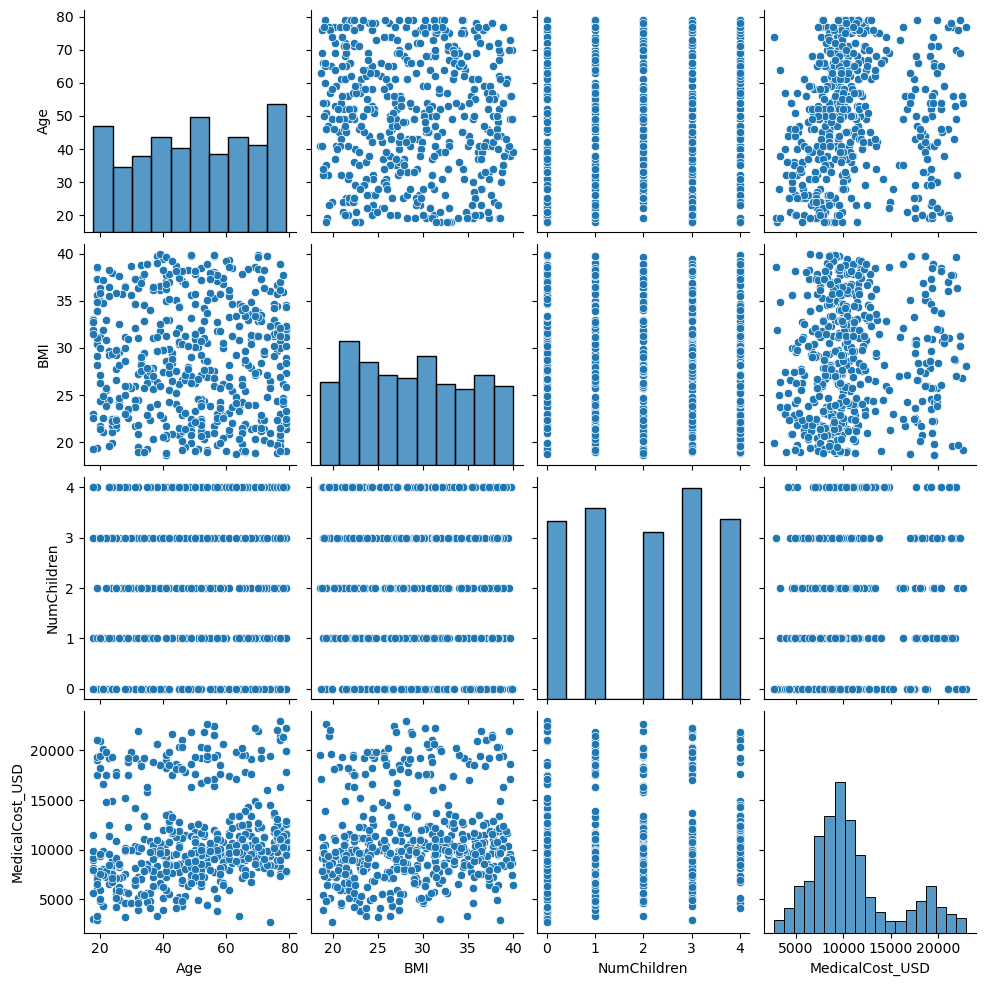

In [80]:
# 데이터 시각화 : pairplot = 여러 숫자형 컬럼을 골라서 서로의 관계를 산점도로 한꺼번에 보여주는 그래프
cols = ['Age', 'BMI', 'NumChildren', 'MedicalCost_USD']
plt.figure(figsize = (10,5))
sns.pairplot(data = df[cols])
plt.show()

## 문제 6-6 | 이진 범주형 변수 숫자 변환

### 📌 문제
`Smoker` 컬럼을 'Yes'는 1로, 'No'는 0으로 변환하는 코드를 작성하세요.

**요구사항:**
- `map` 함수를 사용하여 `Smoker` 컬럼의 값을 변환
- 'Yes' → 1, 'No' → 0으로 매핑


In [81]:
# 데이터 확인
df['Smoker'].head()

0     No
1     No
2    Yes
3     No
4     No
Name: Smoker, dtype: object

In [82]:
# 범주형 숫자 변환
df['Smoker'] = df['Smoker'].map({'Yes' : 1, 'No' : 0})

In [83]:
# 변환 확인
df.head()

,Age,Gender,BMI,Smoker,Region,NumChildren,MedicalCost_USD,NumHospitalizations,ChronicDiseaseCount,MedicationCount
0,56,Female,27.5,0,Southeast,3,11984.32,6.0,0,0
1,69,Male,38.6,0,Northeast,4,14852.63,3.0,0,6
2,46,Female,37.1,1,Southwest,1,21006.62,7.0,0,7
3,32,Male,19.5,0,Southwest,3,7236.76,4.0,3,3
4,60,Male,19.1,0,Northwest,1,9307.46,6.0,0,2


## 문제 6-7 | 범주형 변수 원-핫 인코딩

### 📌 문제
`Gender`와 `Region` 컬럼을 원-핫 인코딩하여 수치형 변수로 변환하세요.

**요구사항:**
- pandas의 `get_dummies` 함수를 사용하여 `Gender`와 `Region` 컬럼에 대해 원-핫 인코딩 수행
- 변환된 결과를 `df_encoded`에 저장


In [84]:
# 데이터 원-핫 인코딩
incod_cols = ['Gender', 'Region']
df = pd.get_dummies(data = df, columns = incod_cols)

In [85]:
# 인코딩 결과 확인
df.columns

Index(['Age', 'BMI', 'Smoker', 'NumChildren', 'MedicalCost_USD',
       'NumHospitalizations', 'ChronicDiseaseCount', 'MedicationCount',
       'Gender_Female', 'Gender_Male', 'Region_Northeast', 'Region_Northwest',
       'Region_Southeast', 'Region_Southwest'],
      dtype='object')

In [86]:
# 변수 할당
df_encoded = df.copy()

## 문제 6-8 | 데이터 분리

### 📌 문제
`MedicalCost_USD`를 예측하기 위해 데이터를 Target(y)과 Feature(X)로 분리하세요.

**요구사항:**
- `MedicalCost_USD` 컬럼을 y 변수에, 나머지 컬럼들을 X 변수에 저장
- X와 y의 shape을 출력하여 확인


In [87]:
# 타겟, 피처 데이터 분리
X = df_encoded.drop(columns = 'MedicalCost_USD')
y = df_encoded['MedicalCost_USD']

In [88]:
# 분리 확인
print(X.shape, y.shape)

(500, 13) (500,)


## 문제 6-9 | 훈련/검증 데이터셋 분리 및 스케일링

### 📌 문제
X와 y를 훈련 데이터와 검증 데이터로 나누고, StandardScaler를 사용하여 모든 특성(Feature)을 스케일링하세요.

**요구사항:**
1. `train_test_split`을 사용하여 훈련 데이터(80%)와 검증 데이터(20%)로 분할
   - `random_state=42`로 설정
2. `StandardScaler`를 사용하여 X_train과 X_valid를 스케일링
   - `sklearn.preprocessing`의 `StandardScaler` 사용


In [89]:
# 라이브러리 임포트
from sklearn.model_selection import train_test_split

In [90]:
# 훈련 / 검증 데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size = 0.2)

In [91]:
# 데이터 분리 확인
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

(400, 13) (100, 13) (400,) (100,)


In [92]:
# 데이터 스케일링 라이브러리 임포트
from sklearn.preprocessing import StandardScaler

In [93]:
# 모델 객체 생성
scaler = StandardScaler()

In [94]:
# 데이터 스케일링
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

## 문제 6-10 | 머신러닝 모델 학습 (Gradient Boosting Regressor)

### 📌 문제
GradientBoostingRegressor 모델을 생성하고 학습하는 코드를 작성하세요.

**요구사항:**
- `sklearn.ensemble`의 `GradientBoostingRegressor` 모델 사용
- 모델의 `n_estimators`는 200, `learning_rate`는 0.1, `random_state`는 42로 설정
- 훈련 데이터(X_train_scaled, y_train)로 모델을 학습


In [95]:
# 라이브러리 임퐅
from sklearn.ensemble import GradientBoostingRegressor

In [96]:
# 모델 객체 생성
gbr_model = GradientBoostingRegressor(n_estimators = 200, random_state = 42, learning_rate = 0.1)

In [97]:
# 훈련 데이터 학습
gbr_model.fit(X_train_scaled, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## 문제 6-11 | 머신러닝 모델 학습 (Lasso Regressor)

### 📌 문제
Lasso 회귀 모델을 생성하고 학습하는 코드를 작성하세요.

**요구사항:**
- `sklearn.linear_model`의 `Lasso` 모델 사용
- 모델의 `alpha`는 0.1로 설정
- 훈련 데이터(X_train_scaled, y_train)로 모델을 학습


In [98]:
# 라이브러리 임포트
from sklearn.linear_model import Lasso

In [99]:
# 모델 객체 생성
lasso_model = Lasso(alpha = 0.1)

In [100]:
# 모델 학습
lasso_model.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


## 문제 6-12 | 딥러닝 모델 개발 및 학습

### 📌 문제
tensorflow.keras를 사용하여 의료비를 예측하는 딥러닝 모델을 만들고 학습하세요.

**요구사항:**
1. Sequential 모델 생성
2. 은닉층이 Hidden Layer를 3개로 구성 (64개, 32개, 16개 뉴런)
3. 첫 번째 은닉층 뒤에 Batch Normalization 레이어 적용
4. 모든 은닉 레이어의 활성화 함수는 'relu'
5. 출력 레이어는 활성화 함수가 'linear' (회귀 문제이므로)
6. 손실 함수는 `mean_squared_error`로 설정하고, 옵티마이저는 'adam', 평가지표는 'mae', 'mse' 사용
7. `epochs=50`, `batch_size=64`로 설정하여 학습


In [101]:
# 라이브러리 임포트
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, BatchNormalization
from tensorflow.keras.models import Sequential

In [102]:
# 모델 생성
dl_model = Sequential([
    Input(shape = (X_train_scaled.shape[1], )), 
    Dense(64, activation = 'relu'),
    BatchNormalization(),
    Dense(32, activation = 'relu'),
    Dense(16, activation = 'relu'),
    Dense(1, activation = 'linear')
])

In [103]:
# 모델 컴파일
dl_model.compile(
    optimizer = 'adam', 
    loss = 'mean_squared_error',
    metrics = ['mae', 'mse']
)

In [104]:
# 모델 학습 
history = dl_model.fit(
    X_train_scaled, 
    y_train,
    epochs = 50, 
    batch_size = 64, 
    validation_data = (X_valid_scaled, y_valid)
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 140218096.0000 - mae: 10927.1885 - mse: 140218096.0000 - val_loss: 143701408.0000 - val_mae: 11108.2275 - val_mse: 143701408.0000
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 140203248.0000 - mae: 10926.5566 - mse: 140203248.0000 - val_loss: 143695152.0000 - val_mae: 11107.9658 - val_mse: 143695152.0000
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 140187680.0000 - mae: 10925.8945 - mse: 140187680.0000 - val_loss: 143687632.0000 - val_mae: 11107.6572 - val_mse: 143687632.0000
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 140170224.0000 - mae: 10925.1689 - mse: 140170224.0000 - val_loss: 143678336.0000 - val_mae: 11107.2773 - val_mse: 143678336.0000
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 140149824.0000 - mae: 10924.3389 - mse: 140149824.0000 - val_loss: 143666704.0000 - val_mae: 11106.8086 - val_mse: 143666704.0000
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 14012606

## 문제 6-13 | 딥러닝 모델 학습 성능 시각화

### 📌 문제
`matplotlib`을 활용하여 딥러닝 모델의 학습 MAE와 검증 MAE를 그래프로 시각화하세요.

**요구사항:**
- `history` 변수에 저장된 학습 과정 데이터를 활용
- 'Training MAE'와 'Validation MAE'를 그래프로 그리기
- x축에 'Epochs', y축에 'MAE'라는 레이블 지정


In [105]:
history.history.keys()

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])

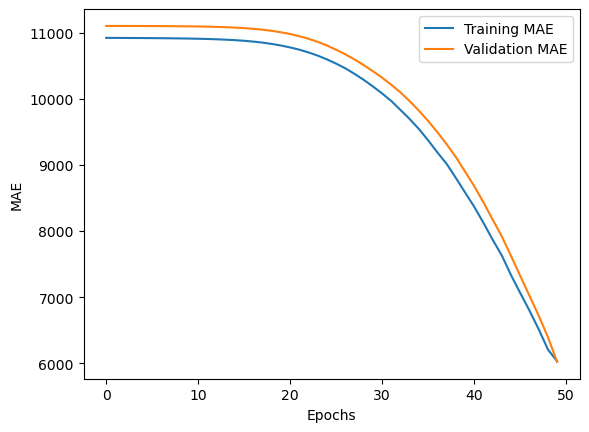

In [106]:
plt.plot(history.history['mae'], label = 'Training MAE')
plt.plot(history.history['val_mae'], label = 'Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

## 문제 6-14 | 최종 모델 성능 평가 및 결론 도출

### 📌 문제
세 가지 모델(`gbr_model`, `lasso_model`, `model`)의 성능을 검증 데이터(X_valid_scaled)에 대해 비교하고, 
가장 우수한 성능을 보인 모델을 선택하세요.

**요구사항:**
1. 각 모델의 R-squared 점수와 MAE를 평가지표로 사용하여 검증 데이터에서 성능 측정
2. `sklearn.metrics`의 `r2_score`와 `mean_absolute_error` 함수 사용
3. 세 모델 중 R-squared 값이 가장 높은 모델을 최종 모델로 선택하여 `best_model_name` 변수에 저장하고, 각 모델의 MAE도 함께 비교하여 출력


In [107]:
# 라이브러리 임포트
from sklearn.metrics import r2_score, mean_absolute_error

In [108]:
## 데이터 예측 
gbr_pred = gbr_model.predict(X_valid_scaled)
lasso_pred = lasso_model.predict(X_valid_scaled)
dl_pred = dl_model.predict(X_valid_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [109]:
# 모델 성능 검증
gbr_r2 = r2_score(y_valid, gbr_pred)
lasso_r2 = r2_score(y_valid, lasso_pred)
dl_r2 = r2_score(y_valid, dl_pred)

In [120]:
score = {'Gradient Boost Regressor' : gbr_r2, 'Lasso' : lasso_r2, 'Deep Learning' : dl_r2}
best_model_name = max(score, key = score.get)
print(best_model_name)

Lasso


In [112]:
# MAE 비교
gbr_mae = mean_absolute_error(y_valid, gbr_pred)
lasso_mae = mean_absolute_error(y_valid, lasso_pred)
dl_mae = mean_absolute_error(y_valid, dl_pred)

In [118]:
mae = {'GBR' : gbr_mae, 'Lasso' : lasso_mae, 'Deep Learning' : dl_mae}
print(f'{mae}, {mae.get}')    

{'GBR': 1741.3776249263349, 'Lasso': 1575.8347541125977, 'Deep Learning': 6018.5538834960935}, <built-in method get of dict object at 0x000002603BE0DB40>
